In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import norm
from scipy.optimize import minimize
from astropy.timeseries import LombScargle
from scipy import stats
from george import kernels
import george
from astropy.io import fits
from functions import *
from glob import glob
from gp_model_params import info
from tqdm import tqdm
import pickle as pkl
from pathlib import Path
from scipy.interpolate import interp1d
import re
from astropy.table import Table
import itertools

/Users/somayeh/opt/anaconda3/envs/pyt313/lib/python3.13/site-packages/george/metrics.py:103: RuntimeWarning: divide by zero encountered in log
  parameters.append(np.log(metric))


In [2]:
from pathlib import Path
home = str(Path.home())

In [3]:
def generate_flare(gp, y,  t_flare):
    mean, cov = gp.predict(y, t_flare)
    return mean

In [94]:
all_templates = {}
tp = 'Flares_TESS'
tic_id = '201292296'
all_templates[tic_id] = {}
# Define file path for the light curve data
path = home+'/Research_data/Bulge_Variables/Flares_TESS/tic%s_rlc.fits'%tic_id
folder_path = home+'/Research_data/Bulge_Variables/%s/'%tp
output_dir = 'output/plots/FL/'

In [95]:
all_paths = glob(folder_path+'*.fits')

In [96]:
# Here we read Roman cadences for the Galactic Bulge
Roman_sampling_short = np.load('lc_example/roman_times_shortcadence.npy')
Roman_sampling_long = np.load('lc_example/roman_times_longcadence.npy')
Roman_sampling_long2 = np.load('lc_example/roman_times_longcadence2.npy')
Roman_sampling_short_min = min(Roman_sampling_short)
Roman_sampling_short = Roman_sampling_short - Roman_sampling_short_min
Roman_sampling_long_min = min(Roman_sampling_long)
Roman_sampling_long = Roman_sampling_long - Roman_sampling_long_min
Roman_sampling_long2_min = min(Roman_sampling_long2)
Roman_sampling_long2 = Roman_sampling_long2 - Roman_sampling_long2_min
Roman_max_short_time = max(Roman_sampling_short)

In [97]:
# for CV, DN, Be stars, we assume period = np.nan
band = 'TESS'
period = np.nan

In [8]:
all_paths[:1]

['/Users/somayeh/Research_data/Bulge_Variables/Flares_TESS/tic234509975_rlc.fits']

/Users/somayeh/opt/anaconda3/envs/pyt313/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/somayeh/opt/anaconda3/envs/pyt313/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/somayeh/Library/Mobile Documents/com~apple~CloudDocs/Research/Roman_lc_gen/functions.py:771: RuntimeWarning: overflow encountered in scalar power
  ll -= smoothness ** s
/Users/somayeh/Library/Mobile Documents/com~apple~CloudDocs/Research/Roman_lc_gen/functions.py:771: RuntimeWarning: overflow encountered in scalar power
  ll -= smoothness ** s


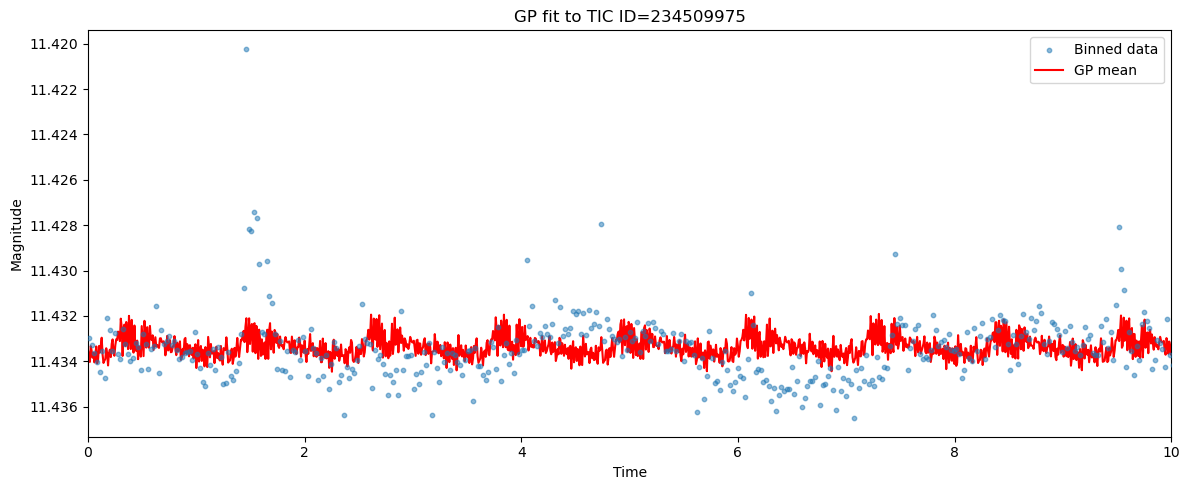

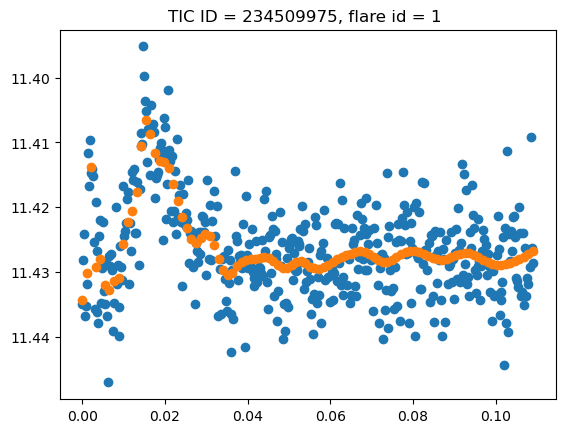

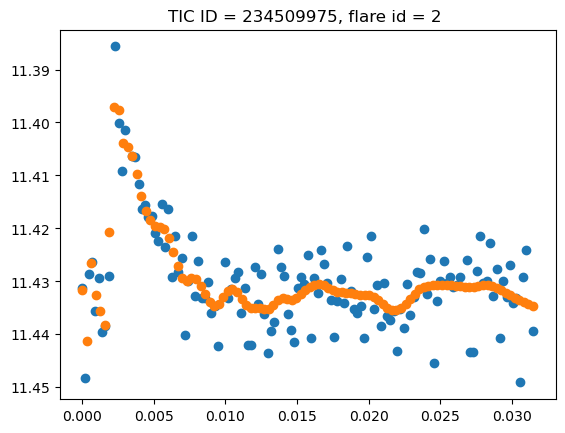

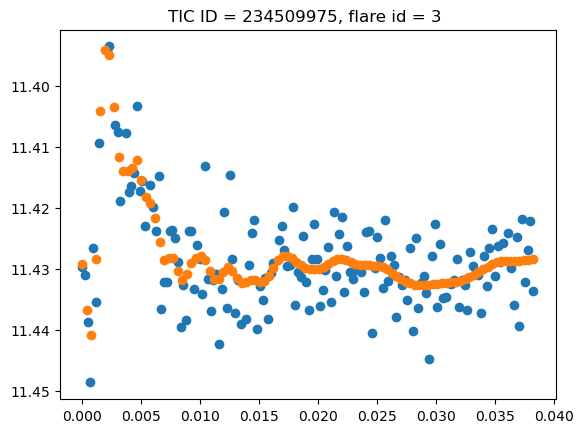

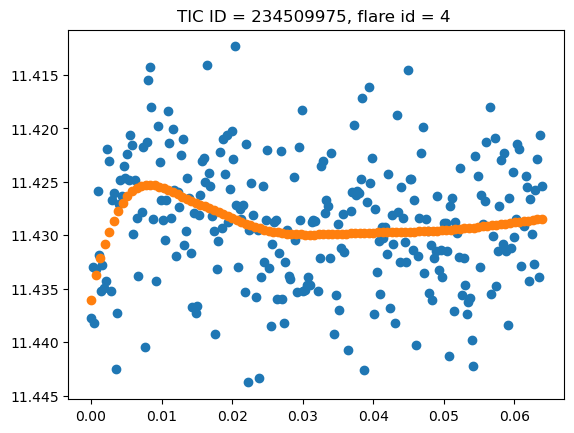

In [11]:
# Testing flare bank creating with one light curve

baseline_bank = {}
flare_bank = {}
info_copy = info[tp].copy()
t_base = Roman_sampling_short
t_base_long = Roman_sampling_long
t_base_long2 = Roman_sampling_long2
t_regular = np.linspace(0, max(Roman_sampling_short), 750000)



for path in all_paths[:1]:
    tic_id = path.split('/')[-1].split('_')[0].split('c')[-1]
    with fits.open(path) as hdul:
        h = hdul[1].header
        hd = hdul[1].data
    t = Table(hd)

    flares = []
    # find all flare numbers present in the header
    flare_nums = sorted({
        int(re.search(r"F(\d+)", k).group(1))
        for k in h.keys()
        if re.match(r"F\d+-EXT", k)
    })
    
    for n in flare_nums:
        flare = {
            "flare_id": n,
            "ext": h.get(f"F{n}-EXT"),
            "btjd_start": h.get(f"F{n}-BTJD-START"),
            "btjd_peak": h.get(f"F{n}-BTJD-PEAK"),
            "btjd_stop": h.get(f"F{n}-BTJD-STOP"),
            "mag_start": h.get(f"F{n}-MAG-START"),
            "mag_peak": h.get(f"F{n}-MAG-PEAK"),
            "mag_stop": h.get(f"F{n}-MAG-STOP"),
        }
        flares.append(flare)
    
    df_header = pd.DataFrame(flares)
    df_lc = t.to_pandas()
    df = df_lc[["BTJD", "mag", "mag_err"]].rename(columns={"BTJD": "t", "mag": "m", "mag_err": "e"})

    t = df.t.values
    m = df.m.values
    e = df.e.values

    gp, data = rot_var_gp_fit(t, m, e, n_bins = 1000)

    m_data, t_data, m_err = data[0], data[1], data[2]

    


    
    y_base_regular = gp.predict(m_data, t_regular, return_var=True)[0]

    interp_baseline = interp1d(t_regular, y_base_regular, kind='linear', bounds_error=False, fill_value=np.nan)
    y_base = interp_baseline(t_base)
    y_base_long = interp_baseline(t_base_long)
    y_base_long2 = interp_baseline(t_base_long2)

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.scatter(t_data, m_data, s=10, alpha=0.5, label="Binned data", zorder=3)
    ax.plot(t_base, y_base, color="red", lw=1.5, label="GP mean")
    ax.set_xlim(0, 10)          # swap to (0, 1000) for the full extrapolation
    ax.invert_yaxis()
    ax.set_xlabel("Time")
    ax.set_ylabel("Magnitude")
    ax.legend()
    ax.set_title("GP fit to TIC ID=%s"%tic_id)
    plt.tight_layout()
    plt.savefig(output_dir+tic_id+'_gp_baseline.png')
    baseline_bank[tic_id] = {}
    baseline_bank[tic_id]['%s_band_Roman_m_official_sampling_short'%band] = y_base
    baseline_bank[tic_id]['%s_band_Roman_m_official_sampling_long'%band] = y_base_long
    baseline_bank[tic_id]['%s_band_Roman_m_official_sampling_long2'%band] = y_base_long2
    baseline_bank[tic_id]['%s_band_Roman_m_regular_sampling'%band] = y_base_regular
    baseline_bank[tic_id]['%s_band_Roman_time_regular_sampling'%band] = t_regular

    

    

    for f in df_header.flare_id.values:
        if df_header[df_header.flare_id==f].btjd_peak.values[0]>max(df.t.values):
            continue
        fl_start = df_header[df_header.flare_id == f]['btjd_start'].values[0]
        fl_stop = df_header[df_header.flare_id == f]['btjd_stop'].values[0]
        df_fl6 = df[(df.t<fl_stop) & (df.t>fl_start) ]
        if np.min(df_fl6.t) > 0:
            df_fl6.loc[:, 't'] = df_fl6['t'] - np.min(df_fl6['t'])
        x, y, e = prep_input(df_fl6, 
                             tp, 
                             period, 
                             info_copy, 
                             Roman_max_short_time)

        dic = flare_fit(x, y, e, info_copy, period)
        flare_bank[tic_id+'_'+str(f)] = dic
    
        # print(info[tp])
        plt.figure()
        plt.scatter(x, y)
        # plt.plot(dic["xfit"]-min(dic["xfit"]), dic["yfit"])
        plt.scatter(dic["x_new"], dic["y_new"])
        plt.title('TIC ID = %s, flare id = %i '%(tic_id, f))
        plt.gca().invert_yaxis()
        plt.savefig(output_dir+ tic_id+'_'+str(f)+'.png')



    


    
    
    

# Flare fit for a test light curve

In [98]:
with fits.open(path) as hdul:
    h = hdul[1].header
    hd = hdul[1].data
t = Table(hd)

In [99]:
flares = []

# find all flare numbers present in the header
flare_nums = sorted({
    int(re.search(r"F(\d+)", k).group(1))
    for k in h.keys()
    if re.match(r"F\d+-EXT", k)
})

for n in flare_nums:
    flare = {
        "flare_id": n,
        "ext": h.get(f"F{n}-EXT"),
        "btjd_start": h.get(f"F{n}-BTJD-START"),
        "btjd_peak": h.get(f"F{n}-BTJD-PEAK"),
        "btjd_stop": h.get(f"F{n}-BTJD-STOP"),
        "mag_start": h.get(f"F{n}-MAG-START"),
        "mag_peak": h.get(f"F{n}-MAG-PEAK"),
        "mag_stop": h.get(f"F{n}-MAG-STOP"),
    }
    flares.append(flare)

df_header = pd.DataFrame(flares)

df_lc = t.to_pandas()
df = df_lc[["BTJD", "mag", "mag_err"]].rename(columns={"BTJD": "t", "mag": "m", "mag_err": "e"})

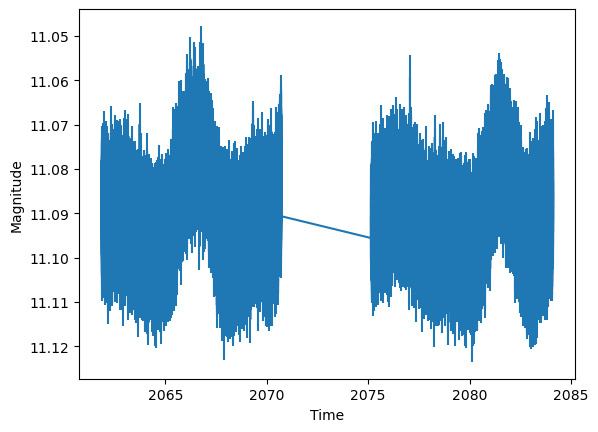

In [100]:
# Plot the light curve
flare_num = 1
plt.errorbar(df.t,
            df.m, 
             yerr=df.e)
plt.xlabel('Time')
plt.ylabel('Magnitude')
plt.gca().invert_yaxis()

In [101]:
# ── 3. Negative log-likelihood + gradient ────────────────────────────────────
def neg_log_like(params, y, x, gp, s):
    gp.set_parameter_vector(params)
    ll = gp.log_likelihood(y, quiet=True)
    return -ll if np.isfinite(ll) else 1e25

def grad_neg_log_like(params, y, x, gp, s):
    gp.set_parameter_vector(params)
    return -gp.grad_log_likelihood(y, quiet=True)

In [102]:
def lomb_scargle_period(t, m, e, min_period=0.5, max_period=500, top_n=5):
    """
    Quick Lomb-Scargle period estimation.
    
    Parameters
    ----------
    t, m, e   : array-like  time, magnitude, uncertainty
    min_period: float       minimum period to search (days)
    max_period: float       maximum period to search (days)
    top_n     : int         number of top peaks to print
    
    Returns
    -------
    period_ls : float       best-fit period (days)
    frequency : ndarray     frequency array
    power     : ndarray     LS power array
    """
    from astropy.timeseries import LombScargle
    from scipy.signal import find_peaks

    frequency, power = LombScargle(t, m, e).autopower(
        minimum_frequency=1 / max_period,
        maximum_frequency=1 / min_period,
    )

    best_freq = frequency[np.argmax(power)]
    period_ls = 1 / best_freq

    fap = LombScargle(t, m, e).false_alarm_probability(power.max())

    peaks, _ = find_peaks(power, height=np.percentile(power, 95))
    top_peaks = sorted(peaks, key=lambda i: power[i], reverse=True)[:top_n]


    return period_ls, frequency, power

In [103]:
t = df.t.values
m = df.m.values
e = df.e.values
n_bins = 1000

# gp, data = rot_var_gp_fit(t, m, e, n_bins = 600)

# m_data, t_data, m_err = data[0], data[1], data[2]

mask = np.isfinite(t) & np.isfinite(m) & np.isfinite(e)
t, m, e = t[mask], m[mask], e[mask]

t_data, m_data, m_err = stats_binning(t-min(t), m, e, bins=n_bins)

t_data = t_data[~np.isnan(m_data)]
m_err = m_err[~np.isnan(m_data)]
m_data = m_data[~np.isnan(m_data)]

period_init, _, _ = lomb_scargle_period(t_data, m_data, m_err)


m_median = np.median(m_data)

s = 0

amplitude   = (np.max(m_data) - np.min(m_data)) / 2
period_init = period_init    # your initial period guess
gamma_init  = 1.0     # sharpness

# k_rbf      = kernels.ExpSquaredKernel(metric=500.0, ndim=1)  # long length-scale
k_periodic = amplitude**2 * kernels.ExpSine2Kernel(
    gamma=gamma_init,
    log_period=np.log(period_init)
)
kernel = k_periodic + kernels.ConstantKernel(1e-6, ndim=1)

gp = george.GP(kernel)
gp.compute(t_data, m_err)


p0 = gp.get_parameter_vector()
bounds = gp.get_parameter_bounds()   # george provides sensible bounds

p0 = gp.get_parameter_vector()
bounds = gp.get_parameter_bounds()   # george provides sensible bounds

result = minimize(
    neg_log_like,
    p0,
    args=(m_data, t_data, gp, s),
    jac=grad_neg_log_like,
    method="L-BFGS-B",
    bounds=bounds,
)

gp.set_parameter_vector(result.x)

t_data = t_data-min(t_data)

# print(f"Optimised gamma  : {gp.get_parameter('kernel:k2:gamma'):.4f}")
# print(f"Optimised ln(amp): {gp.get_parameter('kernel:k1:log_constant'):.4f}")

# ── 5. Predict (GP posterior mean + variance) ─────────────────────────────────
# t_future  = np.linspace(0, 1000, 700000)
# mu, var   = gp.predict(m_data, t_future, return_var=True)
# sigma     = np.sqrt(var)

/Users/somayeh/opt/anaconda3/envs/pyt313/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/somayeh/opt/anaconda3/envs/pyt313/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


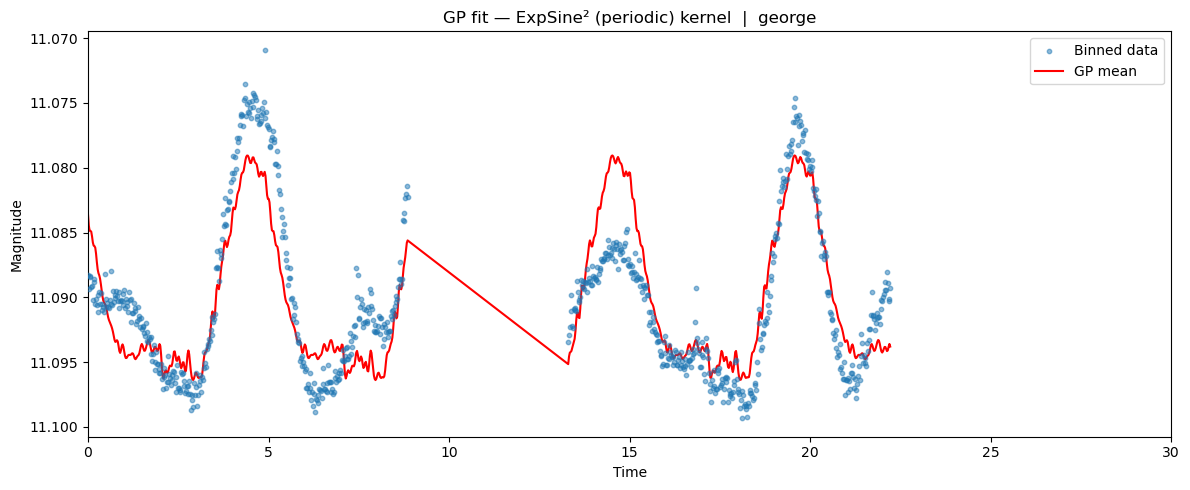

In [104]:
fig, ax = plt.subplots(figsize=(12, 5))
m_data_gp = gp.predict(m_data, t_data, return_var=True)[0]
ax.scatter(t_data, m_data, s=10, alpha=0.5, label="Binned data", zorder=3)
ax.plot(t_data, m_data_gp, color="red", lw=1.5, label="GP mean")
# ax.fill_between(
#     t_future,
#     mu+m_median - 2*sigma, mu+m_median + 2*sigma,
#     color="red", alpha=0.15, label="GP ±2σ"
# )
ax.set_xlim(0, 30)          # swap to (0, 1000) for the full extrapolation
ax.invert_yaxis()
ax.set_xlabel("Time")
ax.set_ylabel("Magnitude")
ax.legend()
ax.set_title("GP fit — ExpSine² (periodic) kernel  |  george")
plt.tight_layout()
plt.show()

In [76]:
np.sum(np.abs(m_data-m_data_gp)**2 )

np.float64(0.0010143055622399842)

In [22]:
fl_start = df_header[df_header.flare_id == flare_num]['btjd_start'].values[0]
fl_stop = df_header[df_header.flare_id == flare_num]['btjd_stop'].values[0]
t0 = df_header[df_header.flare_id == flare_num]['btjd_peak'].values[0]
df_fl6 = df[(df.t<fl_stop) & (df.t>fl_start) ]

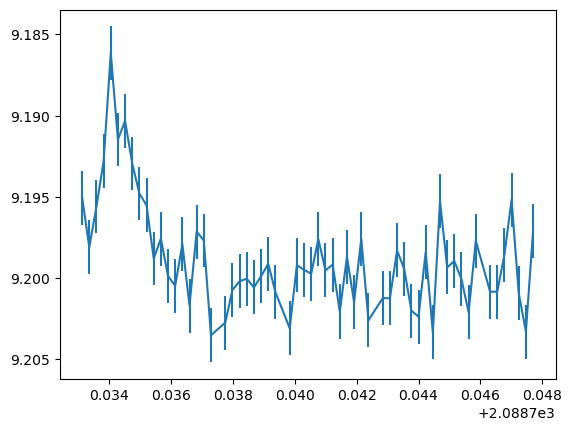

In [23]:
plt.errorbar(df_fl6.t,
            df_fl6.m, 
             yerr=df_fl6.e)
plt.gca().invert_yaxis()

In [24]:
# Normalize time axis
if np.min(df_fl6.t) > 0:
    df_fl6.t = df_fl6.t - np.min(df_fl6.t)

/var/folders/6f/k2kn3hn52ws4kc_w0_zqfpy40000gp/T/ipykernel_55437/700951060.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fl6.t = df_fl6.t - np.min(df_fl6.t)


In [27]:
# Prepare input for Gaussian Process
# info[tp]['gp_opt_s_param'] = 1
# info[tp]['p0'][1] = 3
# info[tp]['p0'][0] = 1
info_copy = info[tp].copy()
gp = prep_gp(info_copy, period)

x, y, e = prep_input(df_fl6, 
                     tp, 
                     period, 
                     info_copy, 
                     Roman_max_short_time)# x, y, e are either 
                                    # the full lc or an intrval 
                                    # of n phases of them conducted 
                                    # by repeating a folded phase n times

In [28]:
# info[tp]['gp_opt_s_param'] = 0.1
# info[tp]['p0'][1] = 0.005
# info[tp]['p0'][0] = 2
gp = fit_gp(-1*np.log10(x+0.001), y, e, info_copy, gp)

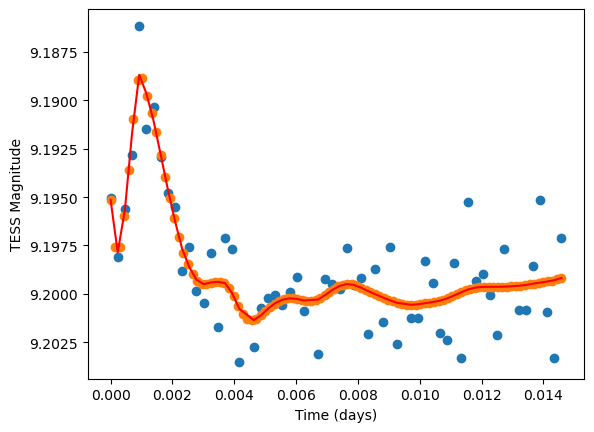

In [29]:
gp_y_binned_fit, cov_tmp = gp.predict(y, -1*np.log10(x+0.001))
x_new = np.linspace(0, max(x), 100)
gp_y_binned_fit2, cov_tmp2 = gp.predict(y, -1*np.log10(x_new+0.001))
plt.scatter(x, y)
plt.plot(x, gp_y_binned_fit, 'r')
plt.scatter(x_new, gp_y_binned_fit2)
plt.xlabel('Time (days)')
plt.ylabel('TESS Magnitude')
plt.gca().invert_yaxis()

In [30]:
import numpy as np
import pandas as pd

length = max(Roman_sampling_short)
cadence = np.median(np.diff(Roman_sampling_short))

t_base = Roman_sampling_short
t_base_long = Roman_sampling_long
t_regular = np.linspace(0, max(Roman_sampling_short), 73650)

baseline_mag = np.median(y)   # your quiescent magnitude
y_base = np.ones_like(t_base) * baseline_mag + np.random.normal(0, 0.001, size=len(t_base))
y_base_long = np.ones_like(t_base_long) * baseline_mag + np.random.normal(0, 0.001, size=len(t_base_long))
y_base_regular = y_base = np.ones_like(t_regular) * baseline_mag + np.random.normal(0, 0.001, size=len(t_regular))

In [48]:
def flare_fit(flare_id, df_header, x, y, e, info_copy, period):
    gp = prep_gp(info_copy, period)

    gp = fit_gp(-1*np.log10(x+0.001), y, e, info_copy, gp)
    
    yfit = gp.predict(y, -1*np.log10(x+0.001))[0]
    
    x_new = np.linspace(0, max(x), 100)
    gp_y_binned_fit2, cov_tmp2 = gp.predict(y, -1*np.log10(x_new+0.001))

    return {
        "gp": gp,
        "xfit": -1*np.log10(x+0.001),
        "yfit": yfit,
        "x": x,        # original flare time grid
        "y": y,
        "x_new":x_new,
        "y_new":gp_y_binned_fit2
    }

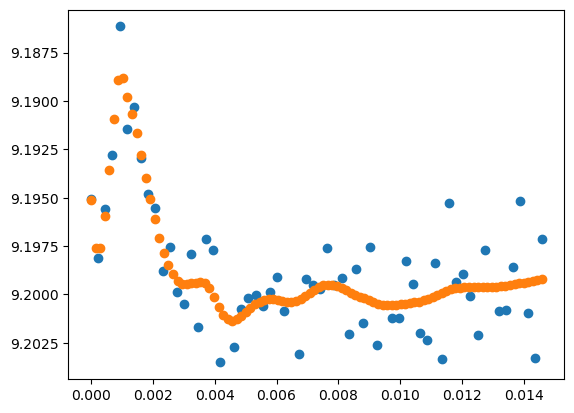

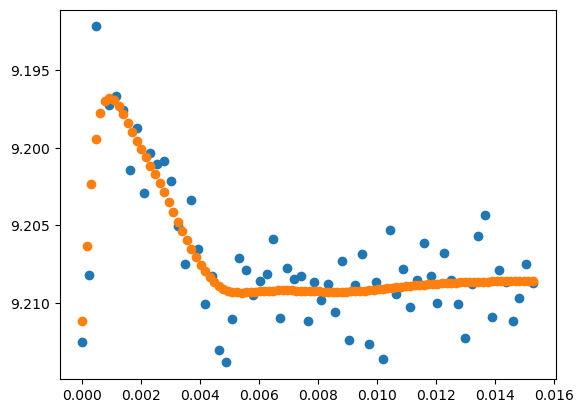

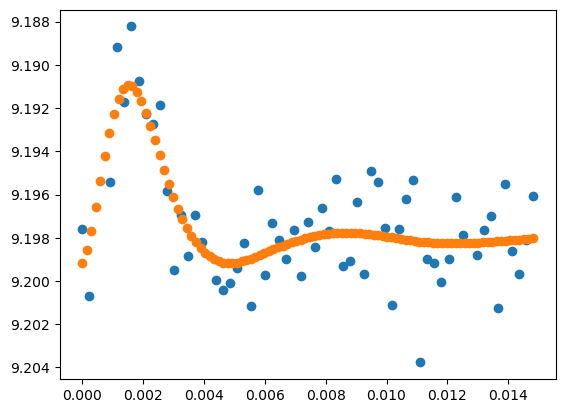

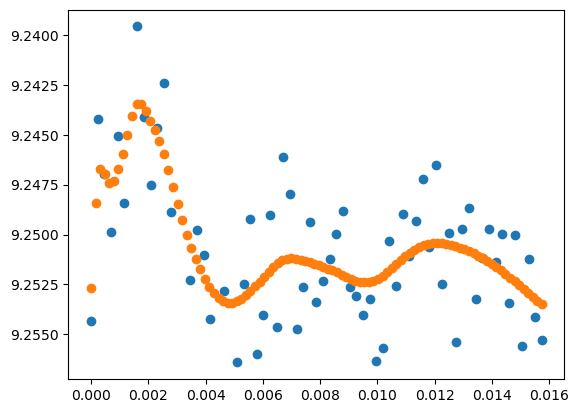

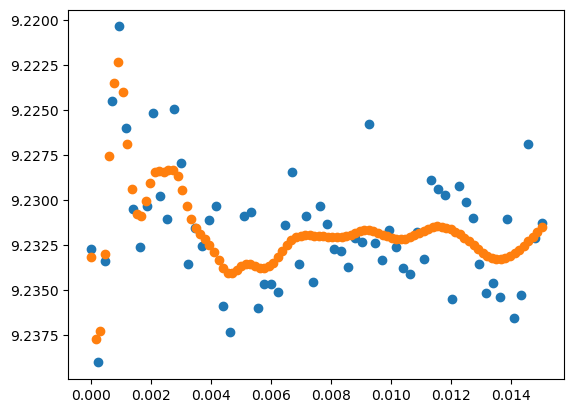

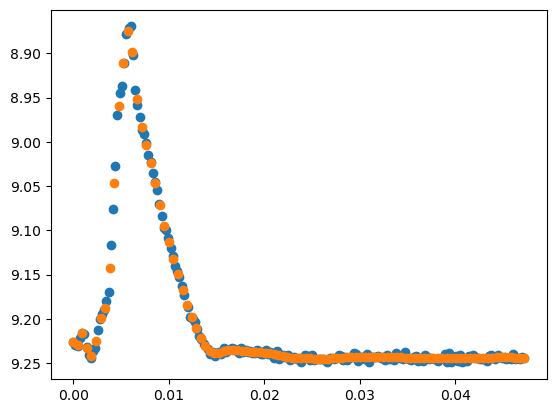

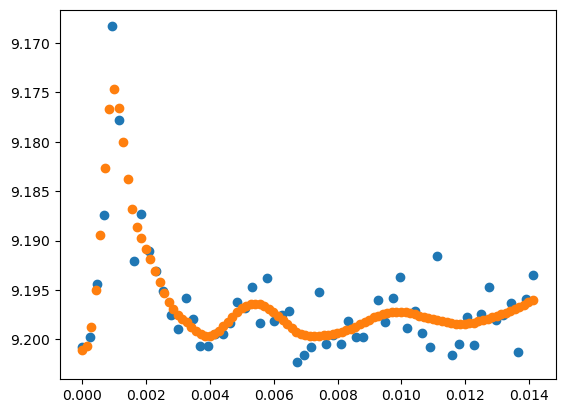

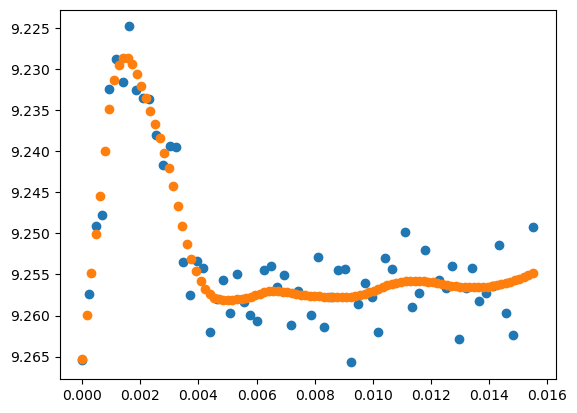

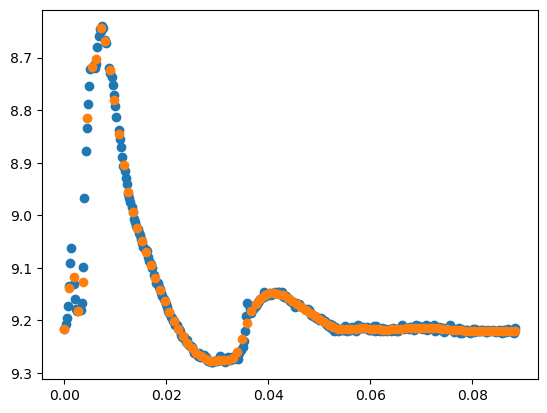

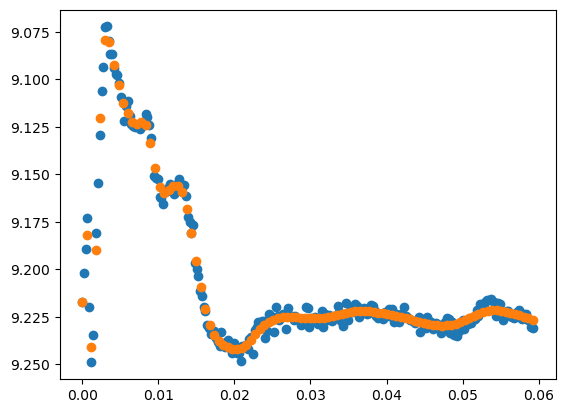

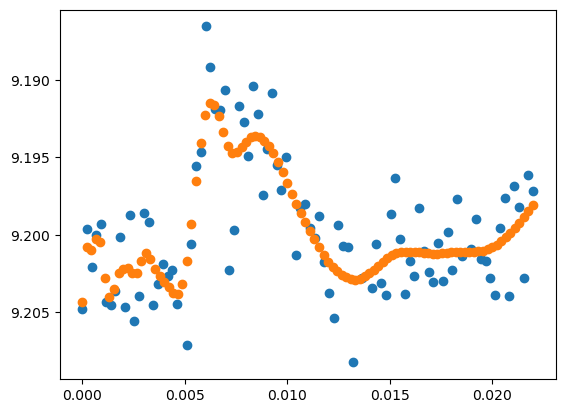

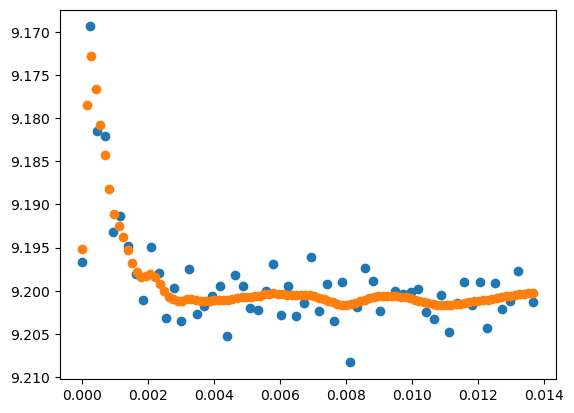

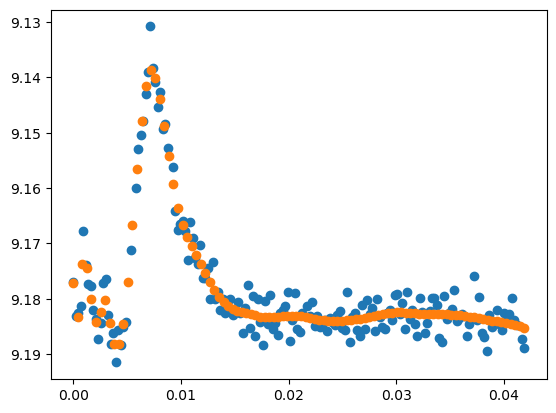

In [50]:
flare_models = []
info[tp]['gp_opt_s_param'] = 1
info[tp]['p0'][1] = 3
info[tp]['p0'][0] = 1
info_copy = info[tp].copy()

for f in df_header.flare_id.values:
    if df_header[df_header.flare_id==f].btjd_peak.values[0]>max(df.t.values):
        continue
    fl_start = df_header[df_header.flare_id == f]['btjd_start'].values[0]
    fl_stop = df_header[df_header.flare_id == f]['btjd_stop'].values[0]
    df_fl6 = df[(df.t<fl_stop) & (df.t>fl_start) ]
    if np.min(df_fl6.t) > 0:
        df_fl6.loc[:, 't'] = df_fl6['t'] - np.min(df_fl6['t'])
    x, y, e = prep_input(df_fl6, 
                         tp, 
                         period, 
                         info_copy, 
                         Roman_max_short_time)
    # info[tp]['gp_opt_s_param'] = 3
    # info[tp]['p0'][1] = 3
    # info[tp]['p0'][0] = 2
    # gp = fit_gp(-1*np.log10(x+0.001), y, e, info_copy, gp)

    # yfit = gp.predict(y, -1*np.log10(x+0.001))[0]

    # x_new = np.linspace(0, max(x), 100)
    # gp_y_binned_fit2, cov_tmp2 = gp.predict(y, -1*np.log10(x_new+0.001))

    # dic = {
    #     "gp": gp,
    #     "xfit": -1*np.log10(x+0.001),
    #     "yfit": yfit,
    #     "x": x,        # original flare time grid
    #     "y": y,
    #     "x_new":x_new,
    #     "y_new":gp_y_binned_fit2
    # }
    # flare_models.append(dic)

    dic = flare_fit(f, df_header, x, y, e, info_copy, period)
    flare_models.append(dic)

    # print(info[tp])
    plt.figure()
    plt.scatter(x, y)
    # plt.plot(dic["xfit"]-min(dic["xfit"]), dic["yfit"])
    plt.scatter(dic["x_new"], dic["y_new"])
    plt.gca().invert_yaxis()

In [38]:
n_flares = len(flare_models)

In [39]:
coeff = max(t_base)/(max(df.t)-min(df.t))

In [66]:
import itertools

data = [int(v) for v in np.linspace(0, n_flares-1, int(n_flares-1))]
unique_pairs = set()

for r in range(1, len(data) + 1):
    for c in itertools.combinations(data, r):
        unique_pairs.add(c)

# print(sorted(list(unique_pairs), key=len))

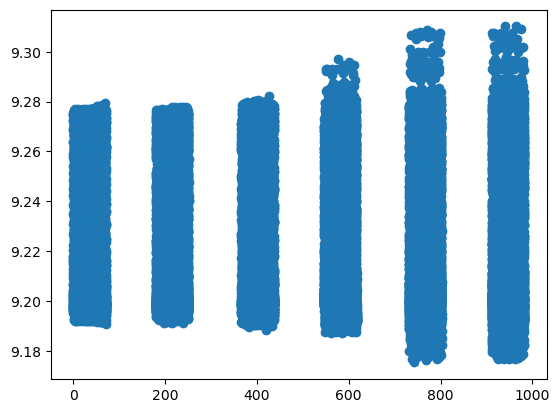

In [67]:
plt.scatter(t_base, gp.predict(m_data, t_base, return_var=True)[0])

# Baseline selection and flare injection for a single light curve

In [106]:
with open('output/flares/flare_baseline_bank.pkl', 'rb') as file:
    baseline_bank = pkl.load(file)

In [107]:
with open('output/flares/flare_gp_fit_bank.pkl', 'rb') as file:
    flare_bank = pkl.load(file)

In [208]:
# Injecting flare models into Roman short and long cadence baseline, 
# and a regularly-sampled gapless baseline

num_lc = 1

make_flat = ['117874959',
             '158624542',
             '197829751']

all_flares = len(list(flare_bank.keys()))
flare_keys = list(flare_bank.keys())
all_baselines = len(list(baseline_bank.keys()))

all_lc = {}

for i in range(num_lc):
    
    tic_id = np.random.choice(list(baseline_bank.keys()), size=1)[0]
    n_flares = int(np.random.choice(np.linspace(0, all_flares-1, all_flares-1, dtype=int), size=1)[0])
    flare_inds = np.random.choice(flare_keys, size=n_flares)

    if str(tic_id) in make_flat:

        t_regular = baseline_bank[tic_id]['%s_band_Roman_time_regular_sampling'%band]
        
        baseline_mag = np.median(baseline_bank[tic_id]['%s_band_Roman_m_official_sampling_short'%band])   # your quiescent magnitude
        y_base = np.ones_like(t_base) * baseline_mag + np.random.normal(0, 0.001, size=len(t_base))
        y_base_long = np.ones_like(t_base_long) * baseline_mag + np.random.normal(0, 0.001, size=len(t_base_long))
        y_base_long2 = np.ones_like(t_base_long2) * baseline_mag + np.random.normal(0, 0.001, size=len(t_base_long2))
        y_base_regular = np.ones_like(t_regular) * baseline_mag + np.random.normal(0, 0.001, size=len(t_regular))
    
    else:
        y_base = baseline_bank[tic_id]['%s_band_Roman_m_official_sampling_short'%band]
        y_base_long = baseline_bank[tic_id]['%s_band_Roman_m_official_sampling_long'%band]
        y_base_long2 = baseline_bank[tic_id]['%s_band_Roman_m_official_sampling_long2'%band]
        y_base_regular = baseline_bank[tic_id]['%s_band_Roman_m_regular_sampling'%band]
        t_regular = baseline_bank[tic_id]['%s_band_Roman_time_regular_sampling'%band]
        
    y_sim = y_base.copy()
    y_sim_long = y_base_long.copy()
    y_sim_long2 = y_base_long2.copy()
    y_sim_regular = y_base_regular.copy()
    
    flare_times = np.random.choice(t_base, size=n_flares)
    
    for j, flare_ind in enumerate(flare_inds):
        # print(flare_ind)
        
        flare = flare_bank[flare_ind]
        gp = flare["gp"]
        xfit_flare = flare["xfit"]
        xflare = flare["x"]
        flare_tmax = flare["x"][np.argmin(flare["yfit"])]
        tmin_flare = flare_tmax - xflare.min()
        tmax_flare = xflare.max() - flare_tmax   
        interp_y1 = interp1d(flare["x_new"], flare["y_new"], kind='linear', bounds_error=False, fill_value=np.nan)
    
        t0 = flare_times[j]
        mask = (t_base > t0 - tmin_flare) & (t_base < t0 + tmax_flare)
        mask_regular = (t_regular > t0 - tmin_flare) & (t_regular < t0 + tmax_flare)

        t_local = t_base[mask] - t_base[mask].min() + tmin_flare
        t_local_regular = t_regular[mask_regular] - t_regular[mask_regular].min() + tmin_flare
        
        flare_mag = interp_y1(t_local)
        flare_mag_regular = interp_y1(t_local_regular)
            
        y_sim[mask] += flare_mag-max(flare_mag)
        y_sim_regular[mask_regular] += flare_mag_regular-max(flare_mag_regular)

        # try:
        mask_long = (t_base_long > t0 - tmin_flare) & (t_base_long < t0 + tmax_flare)
        if np.sum(mask_long)!=0:
            t_local_long = t_base_long[mask_long] - t_base_long[mask_long].min() + tmin_flare
            flare_mag_long = interp_y1(t_local_long)
            y_sim_long[mask_long] += flare_mag_long-max(flare_mag_long)

        mask_long2 = (t_base_long2 > t0 - tmin_flare) & (t_base_long2 < t0 + tmax_flare)
        if np.sum(mask_long2)!=0:
            t_local_long2 = t_base_long2[mask_long2] - t_base_long2[mask_long2].min() + tmin_flare
            flare_mag_long2 = interp_y1(t_local_long2)
            y_sim_long[mask_long2] += flare_mag_long2-max(flare_mag_long2)
        # except:
        #     pass
            
    


IndexError: boolean index did not match indexed array along axis 0; size of axis is 750000 but size of corresponding boolean axis is 50700

In [211]:
len(y_base)

750000

(790.0, 800.0)

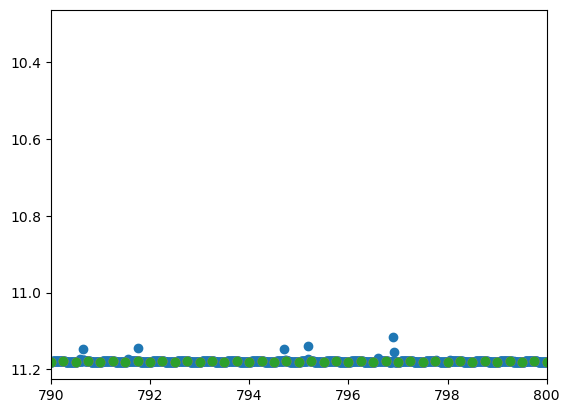

In [191]:
# plt.scatter(t_base, y_base)
plt.scatter(t_base, y_sim)
plt.scatter(t_base_long, y_sim_long)
plt.scatter(t_base_long2, y_sim_long2)
# plt.scatter(t_regular, y_sim_regular)
plt.gca().invert_yaxis()
plt.xlim(790, 800)
# plt.ylim(10.91, 10.90)

259845346


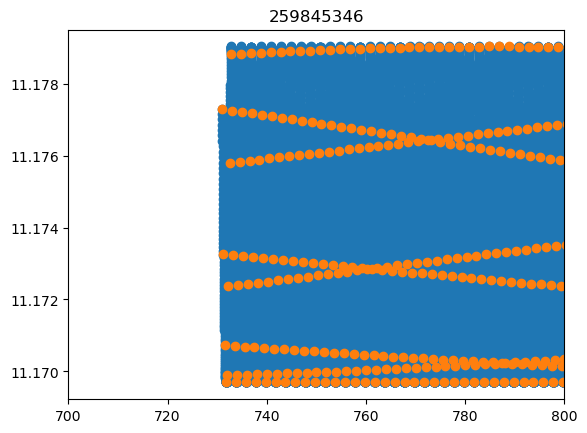

In [213]:
for key in baseline_bank.keys():
    if key == '259845346':
        print(key)
        plt.figure()
        plt.scatter(t_base, baseline_bank[key]['%s_band_Roman_m_official_sampling_short'%band])
        plt.scatter(t_base_long, baseline_bank[key]['%s_band_Roman_m_official_sampling_long'%band])
        plt.xlim(700, 800)
        plt.title(key)

In [198]:
band = 'TESS'
all_templates[tic_id]['%s_band_m_observation'%band] = df.m.values
all_templates[tic_id]['%s_band_time_bservation'%band] = df.t.values
all_templates[tic_id]['%s_band_flare_files'%band] = flare_models
all_templates[tic_id]['%s_band_Roman_m_official_sampling_short'%band] = all_lc
all_templates[tic_id]['%s_band_Roman_m_official_sampling_long'%band] = all_lc_long
all_templates[tic_id]['%s_band_Roman_m_regular_sampling'%band] = all_lc_regular
all_templates[tic_id]['%s_band_Roman_time_regular_sampling'%band] = t_regular

In [203]:
pkl.dump(all_templates, 
         open(home+'/Desktop/flare_templates/TESS_'+tic_id+'.pkl',
              'wb'))

In [202]:
tic_id

'201289286'

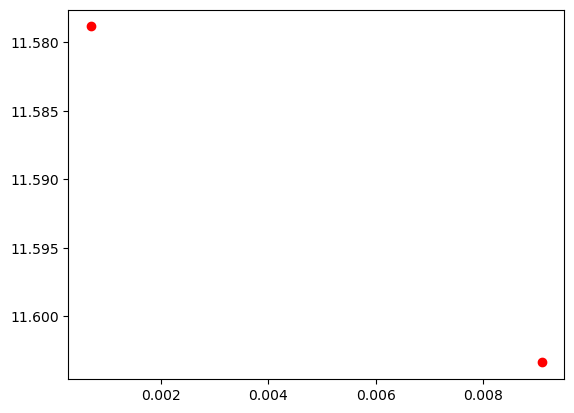

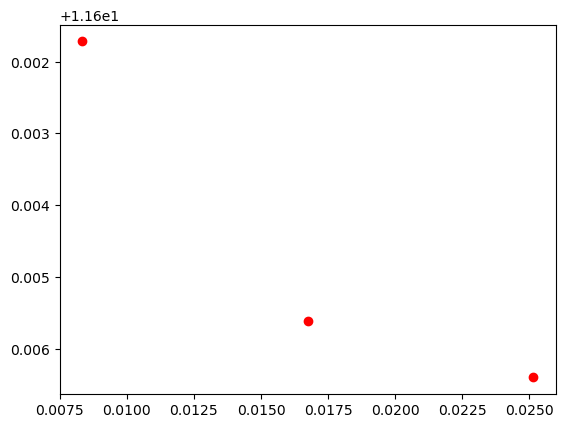

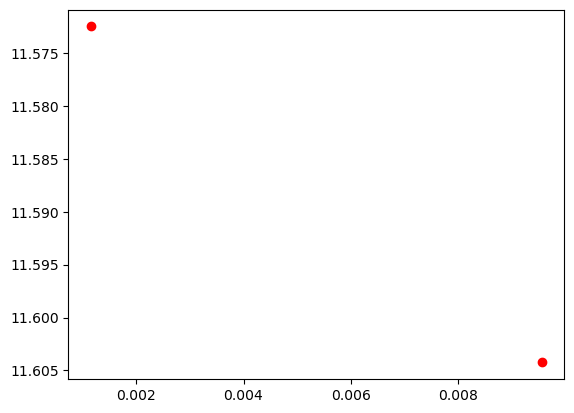

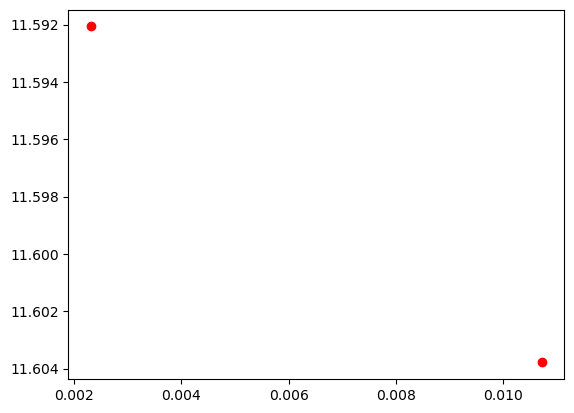

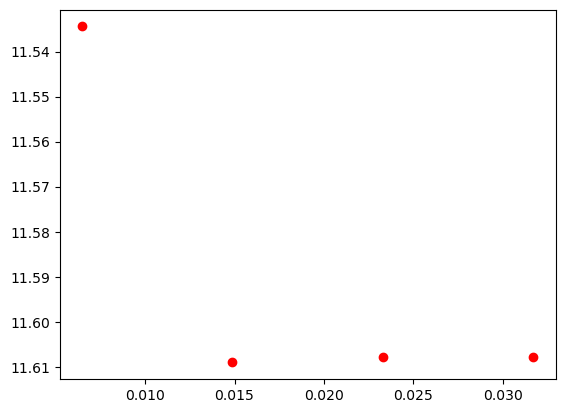

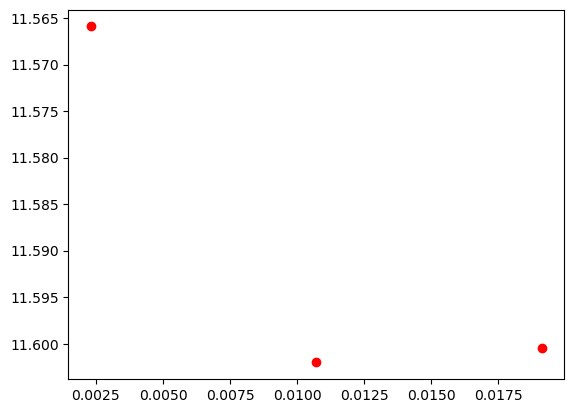

In [207]:


for flare, t0 in zip(flare_models, flare_times):

    gp = flare["gp"]
    xfit_flare = flare["xfit"]
    xflare = flare["x"]
    flare_tmax = flare["x"][np.argmin(flare["yfit"])]
    tmin_flare = flare_tmax - xflare.min()
    tmax_flare = xflare.max() - flare_tmax    

    mask = (t_base > t0 - tmin_flare) & (t_base < t0 + tmax_flare)

    t_local = t_base[mask] - t_base[mask].min() + tmin_flare
    
    interp_y1 = interp1d(flare["x_new"], flare["y_new"], kind='linear', bounds_error=False, fill_value=np.nan)
    flare_mag = interp_y1(t_local)

    # flare_mag = generate_flare(gp, flare["y"], -1*np.log(t_local+0.001))

    y_sim[mask] = flare_mag
    
    plt.figure()
    plt.scatter(t_local, flare_mag, color='r')
    # plt.scatter(x, y)
    # plt.scatter(t_base, y_sim, color='b')
    # plt.axvline(flare_tmax)
    plt.gca().invert_yaxis()

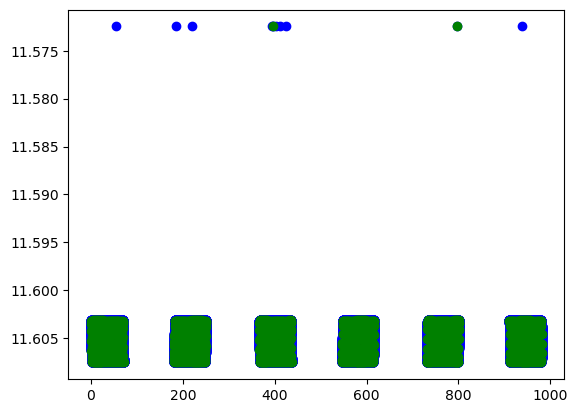

In [189]:
plt.scatter(t_base, all_lc[0], color='b')
plt.scatter(t_base_long, all_lc_long[0], color='g')
# plt.scatter(t_regular, all_lc_regular[0], color='orange')

plt.gca().invert_yaxis()

(400.4, 430.8)

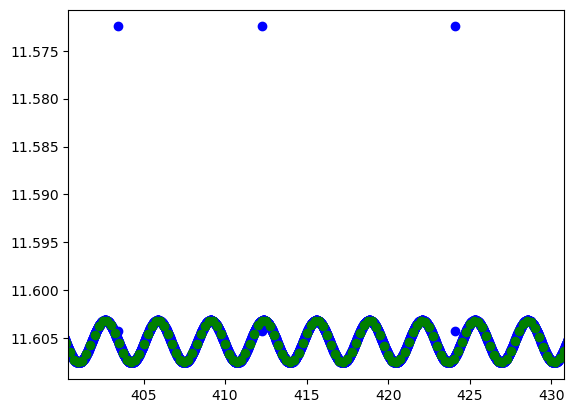

In [192]:
plt.figure()
# plt.scatter(t_local, flare_mag, color='r')
# plt.scatter(x, y)
plt.scatter(t_base, all_lc[0], color='b')
plt.scatter(t_base_long, all_lc_long[0], color='g')
# plt.axvline(flare_tmax)
plt.gca().invert_yaxis()
plt.xlim(400.4, 430.8
        )

In [357]:
xflare

array([2065.10137664, 2065.1020711 , 2065.10230258, 2065.10253407,
       2065.10276556, 2065.10299704, 2065.10322853, 2065.10346001,
       2065.1036915 , 2065.10392299, 2065.10438596, 2065.10461744,
       2065.10484893, 2065.10508042, 2065.1053119 , 2065.10554339,
       2065.10577488, 2065.10600636, 2065.10623785, 2065.10646933,
       2065.10670082, 2065.10693231, 2065.10716379, 2065.10739528,
       2065.10762677, 2065.10785825, 2065.10808974, 2065.10832122,
       2065.10855271, 2065.1087842 , 2065.10901568, 2065.10924717,
       2065.10947865, 2065.10971014, 2065.10994163, 2065.1104046 ,
       2065.11063609, 2065.11086757, 2065.11109906, 2065.11133054,
       2065.11156203, 2065.11179352, 2065.112025  , 2065.11225649,
       2065.11248797, 2065.11271946, 2065.11295095, 2065.11318243,
       2065.11341392, 2065.11364541, 2065.11387689, 2065.11410838,
       2065.11433986, 2065.11457135, 2065.11480284, 2065.11503432,
       2065.11526581, 2065.11549729, 2065.11572878, 2065.11596

In [354]:
len(t_local)

1

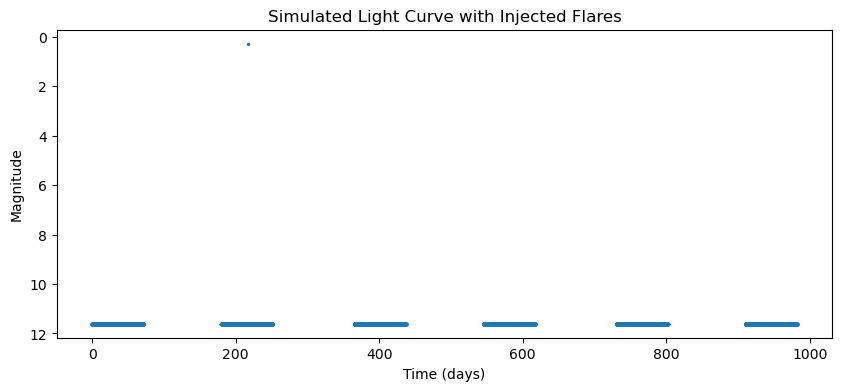

In [338]:
plt.figure(figsize=(10,4))
plt.scatter(t_base, y_sim, s=2)
# plt.axvline(t0)
plt.gca().invert_yaxis()
plt.xlabel("Time (days)")
plt.ylabel("Magnitude")
plt.title("Simulated Light Curve with Injected Flares")
# plt.xlim(t0-0.1, t0+0.1)
plt.show()

ValueError: x and y must have same first dimension, but have shapes (110,) and (61,)

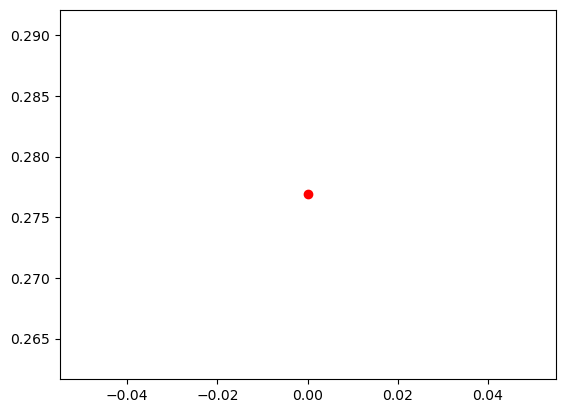

In [339]:
plt.scatter(t_local, flare_mag, color='r')
# plt.scatter(x, y)
plt.plot(x, gp_y_binned_fit, 'r')
plt.axvline(flare_tmax)
plt.gca().invert_yaxis()

In [276]:
tmin_flare

np.float64(0.002314818686045328)

In [273]:
xflare

array([0.        , 0.00023148, 0.00046296, 0.00069445, 0.00092593,
       0.00115741, 0.00185185, 0.00231482, 0.0025463 , 0.00300926,
       0.00324075, 0.00347223, 0.00370371, 0.00393519, 0.00416667,
       0.00439816, 0.00462964, 0.00486112, 0.0050926 , 0.00532408,
       0.00555557, 0.00578705, 0.00601853, 0.00648149, 0.00671297,
       0.00694446, 0.00717594, 0.0076389 , 0.00787038, 0.00810187,
       0.00833335, 0.00856483, 0.00879631, 0.00902779, 0.00925928,
       0.00949076, 0.00972224, 0.00995372, 0.0101852 , 0.01041668,
       0.01064817, 0.01087965, 0.01111113, 0.01134261, 0.01180558,
       0.01203706, 0.01226854, 0.0127315 , 0.01296299, 0.01319447,
       0.01342595, 0.01365743, 0.01388891, 0.01412039, 0.01435188,
       0.01458336, 0.01481484, 0.01504632, 0.0152778 , 0.01550929,
       0.01574077, 0.01597225, 0.01620373, 0.01643521, 0.0166667 ,
       0.01689818, 0.01712966, 0.01736114, 0.01759262, 0.01782411,
       0.01805559, 0.01828707, 0.01851855, 0.01875003, 0.01898